## Censo 2020 ageb

https://www.inegi.org.mx/programas/ccpv/2020/#datos_abiertos (Principales resultados por AGEB y manzana urbana)

In [136]:
import zipfile

path_zip = "../data/raw/ageb_mza_urbana_31_cpv2020_csv.zip"

with zipfile.ZipFile(path_zip, 'r') as z:
    for filename in z.namelist():
        if filename.endswith('.csv'):
            print(filename)

ageb_mza_urbana_31_cpv2020/conjunto_de_datos/conjunto_de_datos_ageb_urbana_31_cpv2020.csv
ageb_mza_urbana_31_cpv2020/diccionario_de_datos/diccionario_datos_ageb_urbana_31_cpv2020.csv


In [142]:
import pandas as pd
import zipfile

path_zip = "../data/raw/ageb_mza_urbana_31_cpv2020_csv.zip"

with zipfile.ZipFile(path_zip, 'r') as z:
    # Busca automáticamente el archivo del conjunto de datos dentro del ZIP
    csv_target = [f for f in z.namelist() if f.endswith('.csv') and 'conjunto_de_datos' in f][0]
    
    with z.open(csv_target) as f:
        df_censo = pd.read_csv(f, encoding='utf-8', low_memory=False)

df_censo.head()

,ENTIDAD,NOM_ENT,MUN,NOM_MUN,LOC,NOM_LOC,AGEB,MZA,POBTOT,POBFEM,...,VPH_TELEF,VPH_CEL,VPH_INTER,VPH_STVP,VPH_SPMVPI,VPH_CVJ,VPH_SINRTV,VPH_SINLTC,VPH_SINCINT,VPH_SINTIC
0,31,Yucatán,0,Total de la entidad Yucatán,0,Total de la entidad,0000,0,2320898,1180619,...,176401,580440,339142,306523,129272,60161,33887,67719,283586,16519
1,31,Yucatán,1,Abalá,0,Total del municipio,0000,0,6550,3247,...,6,1383,345,542,36,15,137,436,1394,78
2,31,Yucatán,1,Abalá,1,Total de la localidad urbana,0000,0,2039,1024,...,*,516,181,323,24,8,28,92,375,14
3,31,Yucatán,1,Abalá,1,Total AGEB urbana,0107,0,843,430,...,*,204,60,104,7,4,11,43,164,7
4,31,Yucatán,1,Abalá,1,Abalá,0107,1,51,32,...,0,11,*,6,0,0,0,*,9,0


In [143]:
df_censo.columns.tolist()

['ENTIDAD',
 'NOM_ENT',
 'MUN',
 'NOM_MUN',
 'LOC',
 'NOM_LOC',
 'AGEB',
 'MZA',
 'POBTOT',
 'POBFEM',
 'POBMAS',
 'P_0A2',
 'P_0A2_F',
 'P_0A2_M',
 'P_3YMAS',
 'P_3YMAS_F',
 'P_3YMAS_M',
 'P_5YMAS',
 'P_5YMAS_F',
 'P_5YMAS_M',
 'P_12YMAS',
 'P_12YMAS_F',
 'P_12YMAS_M',
 'P_15YMAS',
 'P_15YMAS_F',
 'P_15YMAS_M',
 'P_18YMAS',
 'P_18YMAS_F',
 'P_18YMAS_M',
 'P_3A5',
 'P_3A5_F',
 'P_3A5_M',
 'P_6A11',
 'P_6A11_F',
 'P_6A11_M',
 'P_8A14',
 'P_8A14_F',
 'P_8A14_M',
 'P_12A14',
 'P_12A14_F',
 'P_12A14_M',
 'P_15A17',
 'P_15A17_F',
 'P_15A17_M',
 'P_18A24',
 'P_18A24_F',
 'P_18A24_M',
 'P_15A49_F',
 'P_60YMAS',
 'P_60YMAS_F',
 'P_60YMAS_M',
 'REL_H_M',
 'POB0_14',
 'POB15_64',
 'POB65_MAS',
 'PROM_HNV',
 'PNACENT',
 'PNACENT_F',
 'PNACENT_M',
 'PNACOE',
 'PNACOE_F',
 'PNACOE_M',
 'PRES2015',
 'PRES2015_F',
 'PRES2015_M',
 'PRESOE15',
 'PRESOE15_F',
 'PRESOE15_M',
 'P3YM_HLI',
 'P3YM_HLI_F',
 'P3YM_HLI_M',
 'P3HLINHE',
 'P3HLINHE_F',
 'P3HLINHE_M',
 'P3HLI_HE',
 'P3HLI_HE_F',
 'P3HLI_HE_M',
 '

In [144]:
[c for c in df_censo.columns if "AGEB" in c.upper()]

['AGEB']

In [145]:
[c for c in df_censo.columns if "POB" in c.upper()]

['POBTOT',
 'POBFEM',
 'POBMAS',
 'POB0_14',
 'POB15_64',
 'POB65_MAS',
 'POB_AFRO',
 'POB_AFRO_F',
 'POB_AFRO_M',
 'POBHOG']

In [146]:
# Filtrar registros de la ciudad de Mérida
censo_merida = df_censo[
    (df_censo["MUN"] == 50) &
    (df_censo["LOC"] == 1)
].copy()

print("Registros de Mérida:", len(censo_merida))

censo_merida[["MUN", "NOM_MUN", "LOC", "NOM_LOC", "AGEB", "MZA"]].head(10)

Registros de Mérida: 16219


,MUN,NOM_MUN,LOC,NOM_LOC,AGEB,MZA
9728,50,Mérida,1,Total de la localidad urbana,0000,0
9729,50,Mérida,1,Total AGEB urbana,0027,0
9730,50,Mérida,1,Mérida,0027,1
9731,50,Mérida,1,Mérida,0027,2
9732,50,Mérida,1,Mérida,0027,3
9733,50,Mérida,1,Mérida,0027,4
9734,50,Mérida,1,Mérida,0027,5
9735,50,Mérida,1,Mérida,0027,6
9736,50,Mérida,1,Mérida,0027,7
9737,50,Mérida,1,Mérida,0027,8


In [147]:
censo_ageb = censo_merida[
    (censo_merida["NOM_LOC"] == "Total AGEB urbana") &
    (censo_merida["MZA"] == 0)
].copy()

print("AGEB en Censo:", len(censo_ageb))
print("AGEB únicos:", censo_ageb["AGEB"].nunique())

censo_ageb[
    ["MUN", "NOM_MUN", "LOC", "AGEB", "POBTOT", "POB0_14", "POB15_64", "POB65_MAS", "PEA"]
].head()

AGEB en Censo: 483
AGEB únicos: 483


,MUN,NOM_MUN,LOC,AGEB,POBTOT,POB0_14,POB15_64,POB65_MAS,PEA
9729,50,Mérida,1,0027,21,*,19,*,15
9755,50,Mérida,1,0031,253,48,195,10,155
9778,50,Mérida,1,0120,1444,160,947,337,783
9814,50,Mérida,1,0154,186,48,135,3,117
9834,50,Mérida,1,0169,1580,153,979,447,768


In [148]:
ageb_cartografia = set(ageb_merida_ciudad["CVE_AGEB"])
ageb_censo = set(censo_ageb["AGEB"])

print("AGEB en cartografía:", len(ageb_cartografia))
print("AGEB en Censo:", len(ageb_censo))

print("AGEB en ambos:", len(ageb_cartografia & ageb_censo))
print("AGEB solo en cartografía:", len(ageb_cartografia - ageb_censo))
print("AGEB solo en Censo:", len(ageb_censo - ageb_cartografia))

AGEB en cartografía: 483
AGEB en Censo: 483
AGEB en ambos: 483
AGEB solo en cartografía: 0
AGEB solo en Censo: 0


## Marco Geoestadístico. Censo de Población y Vivienda 2020

http://inegi.org.mx/app/biblioteca/ficha.html?upc=889463807469

In [ ]:
%pip install geopandas

177425.93s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [158]:
import geopandas as gpd

print(gpd.__version__)

1.0.1


In [169]:
import zipfile

path_zip = "../data/raw/31_yucatan.zip"

with zipfile.ZipFile(path_zip, 'r') as z:
    shapefiles = [f for f in z.namelist() if f.endswith('.shp')]

for shp in shapefiles:
    print(shp)

conjunto_de_datos/31a.shp
conjunto_de_datos/31ar.shp
conjunto_de_datos/31cd.shp
conjunto_de_datos/31e.shp
conjunto_de_datos/31ent.shp
conjunto_de_datos/31fm.shp
conjunto_de_datos/31l.shp
conjunto_de_datos/31lpr.shp
conjunto_de_datos/31m.shp
conjunto_de_datos/31mun.shp
conjunto_de_datos/31pe.shp
conjunto_de_datos/31pem.shp
conjunto_de_datos/31sia.shp
conjunto_de_datos/31sil.shp
conjunto_de_datos/31sip.shp
conjunto_de_datos/31ti.shp


In [170]:
import os
import pandas as pd
import geopandas as gpd

results = []

for shp in shapefiles:

    path_mapa = f"zip://{path_zip}!{shp}"
    gdf = gpd.read_file(path_mapa)

    results.append({
        "file": os.path.basename(shp),
        "rows": len(gdf),
        "columns": len(gdf.columns),
        "crs": str(gdf.crs),
        "geometry": gdf.geometry.geom_type.unique().tolist(),
        "valid_geometries": gdf.geometry.is_valid.sum()
    })

layers_info = pd.DataFrame(results)
layers_info

,file,rows,columns,crs,geometry,valid_geometries
0,31a.shp,1532,6,"PROJCS[""MEXICO_ITRF_2008_LCC"",GEOGCS[""ITRF2008...","[Polygon, MultiPolygon]",1532
1,31ar.shp,347,5,"PROJCS[""MEXICO_ITRF_2008_LCC"",GEOGCS[""MEXICO_I...","[Polygon, MultiPolygon]",347
2,31cd.shp,422,9,"PROJCS[""MEXICO_ITRF_2008_LCC"",GEOGCS[""ITRF2008...",[MultiPoint],422
3,31e.shp,131304,12,"PROJCS[""MEXICO_ITRF_2008_LCC"",GEOGCS[""ITRF2008...",[LineString],131304
4,31ent.shp,1,4,"PROJCS[""MEXICO_ITRF_2008_LCC"",GEOGCS[""MEXICO_I...",[MultiPolygon],1
5,31fm.shp,226469,27,EPSG:6372,[LineString],226469
6,31l.shp,655,7,"PROJCS[""MEXICO_ITRF_2008_LCC"",GEOGCS[""ITRF2008...","[Polygon, MultiPolygon]",655
7,31lpr.shp,10111,9,"PROJCS[""MEXICO_ITRF_2008_LCC"",GEOGCS[""MEXICO_I...",[Point],10111
8,31m.shp,48021,9,"PROJCS[""MEXICO_ITRF_2008_LCC"",GEOGCS[""ITRF2008...",[Polygon],48021
9,31mun.shp,106,5,"PROJCS[""MEXICO_ITRF_2008_LCC"",GEOGCS[""MEXICO_I...","[Polygon, MultiPolygon]",106


In [172]:
import geopandas as gpd

gdf_31ti = gpd.read_file(
    "zip://../data/raw/31_yucatan.zip!conjunto_de_datos/31ti.shp"
)

gdf_31ti.head()

,CVEGEO,CVE_ENT,CVE_MUN,CVE_AGEB,NOMGEO,geometry
0,310599007,31,059,9007,Arrecife Alacrán,"POLYGON ((3760420.582 1224167.836, 3760701.702..."
1,310599238,31,059,9238,Arrecife Alacrán 11,"POLYGON ((3754140.084 1219696.386, 3754224.75 ..."
2,310599187,31,059,9187,Arrecife Alacrán 9,"POLYGON ((3752160.996 1220368.429, 3752023.413..."
3,310599308,31,059,9308,Arrecife Alacrán 17,"POLYGON ((3752634.558 1216007.797, 3752495.651..."
4,310599454,31,059,9454,Cayo Arenas 3,"POLYGON ((3586483.912 1162398.076, 3586517.061..."


In [173]:
gdf_31ti.columns.tolist()

['CVEGEO', 'CVE_ENT', 'CVE_MUN', 'CVE_AGEB', 'NOMGEO', 'geometry']

In [174]:
gdf_31ti.crs

<Projected CRS: PROJCS["MEXICO_ITRF_2008_LCC",GEOGCS["MEXICO_ITRF_ ...>
Name: MEXICO_ITRF_2008_LCC
Axis Info [cartesian]:
- [east]: Easting (metre)
- [north]: Northing (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: unnamed
- method: Lambert Conic Conformal (2SP)
Datum: International Terrestrial Reference Frame 2008
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [175]:
gdf_31ti.geometry.geom_type.value_counts()

Polygon    54
Name: count, dtype: int64

In [176]:
gdf_31ti.geometry.is_valid.value_counts()

True    54
Name: count, dtype: int64

In [179]:
import geopandas as gpd

path_zip = "../data/raw/31_yucatan.zip"

gdf_31m = gpd.read_file(f"zip://{path_zip}!conjunto_de_datos/31m.shp")
gdf_31a = gpd.read_file(f"zip://{path_zip}!conjunto_de_datos/31a.shp")

print("31m")
print(gdf_31m.columns.tolist())
print(gdf_31m.head())

print("\n31a")
print(gdf_31a.columns.tolist())
print(gdf_31a.head())

31m
['CVEGEO', 'CVE_ENT', 'CVE_MUN', 'CVE_LOC', 'CVE_AGEB', 'CVE_MZA', 'AMBITO', 'TIPOMZA', 'geometry']
             CVEGEO CVE_ENT CVE_MUN CVE_LOC CVE_AGEB CVE_MZA  AMBITO TIPOMZA  \
0  3100100010126002      31     001    0001     0126     002  Urbana  Típica   
1  310010003008A010      31     001    0003     008A     010   Rural  Típica   
2  3100100070018018      31     001    0007     0018     018  Urbana  Típica   
3  3100100070018021      31     001    0007     0018     021  Urbana  Típica   
4  3100100010107029      31     001    0001     0107     029  Urbana  Típica   

                                            geometry  
0  POLYGON ((3776317.318 1014695.955, 3776290.436...  
1  POLYGON ((3785255.76 1012979.803, 3785285.454 ...  
2  POLYGON ((3785798.935 1021132.561, 3785818.269...  
3  POLYGON ((3785159.752 1021511.817, 3785187.686...  
4  POLYGON ((3776873.117 1014643.985, 3776879.112...  

31a
['CVEGEO', 'CVE_ENT', 'CVE_MUN', 'CVE_LOC', 'CVE_AGEB', 'geometry']
          CV

In [180]:
print("31m CRS:", gdf_31m.crs)
print("31m geometrías:", gdf_31m.geometry.geom_type.value_counts())
print("31m válidas:", gdf_31m.geometry.is_valid.value_counts())

print("\n31a CRS:", gdf_31a.crs)
print("31a geometrías:", gdf_31a.geometry.geom_type.value_counts())
print("31a válidas:", gdf_31a.geometry.is_valid.value_counts())

31m CRS: PROJCS["MEXICO_ITRF_2008_LCC",GEOGCS["ITRF2008",DATUM["International_Terrestrial_Reference_Frame_2008",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1061"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",12],PARAMETER["central_meridian",-102],PARAMETER["standard_parallel_1",17.5],PARAMETER["standard_parallel_2",29.5],PARAMETER["false_easting",2500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
31m geometrías: Polygon    48021
Name: count, dtype: int64
31m válidas: True    48021
Name: count, dtype: int64

31a CRS: PROJCS["MEXICO_ITRF_2008_LCC",GEOGCS["ITRF2008",DATUM["International_Terrestrial_Reference_Frame_2008",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1061"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Co

In [181]:
gdf_31a["CVE_MUN"].value_counts()

CVE_MUN
050    526
041     70
059     60
102     45
096     37
      ... 
051      2
021      2
088      2
065      1
061      1
Name: count, Length: 106, dtype: int64

In [182]:
ageb_merida["CVE_AGEB"].nunique()

526

In [183]:
# Municipios disponibles en la capa 31a
print("Municipios:")
print(gdf_31a["CVE_MUN"].value_counts().sort_index())

# Verificar Mérida
print("\n¿Existe CVE_MUN = 050?")
print((gdf_31a["CVE_MUN"] == "050").any())

# Filtrar Mérida
ageb_merida = gdf_31a[
    gdf_31a["CVE_MUN"] == "050"
].copy()

print("\nNúmero de polígonos en Mérida:")
print(len(ageb_merida))

print("\nNúmero de AGEB diferentes:")
print(ageb_merida["CVE_AGEB"].nunique())

print("\nLocalidades dentro de Mérida:")
print(ageb_merida["CVE_LOC"].value_counts())

print("\nPrimeros registros:")
display(ageb_merida.head())

Municipios:
CVE_MUN
001    10
002     4
003    18
004     5
005     3
       ..
102    45
103     5
104     6
105     4
106     3
Name: count, Length: 106, dtype: int64

¿Existe CVE_MUN = 050?
True

Número de polígonos en Mérida:
526

Número de AGEB diferentes:
526

Localidades dentro de Mérida:
CVE_LOC
0001    483
0084     13
0075     10
0093      8
0077      8
0111      4
Name: count, dtype: int64

Primeros registros:


,CVEGEO,CVE_ENT,CVE_MUN,CVE_LOC,CVE_AGEB,geometry
412,3105000015329,31,050,0001,5329,"POLYGON ((3779478.623 1047307.492, 3779480.973..."
413,3105000012466,31,050,0001,2466,"POLYGON ((3777875.435 1056949.722, 3777947.632..."
414,310500001249A,31,050,0001,249A,"POLYGON ((3779713.782 1053802.753, 3779711.8 1..."
415,3105000015827,31,050,0001,5827,"POLYGON ((3772091.762 1052572.146, 3772125.684..."
416,3105000014706,31,050,0001,4706,"POLYGON ((3772829.128 1047931.32, 3772821.774 ..."


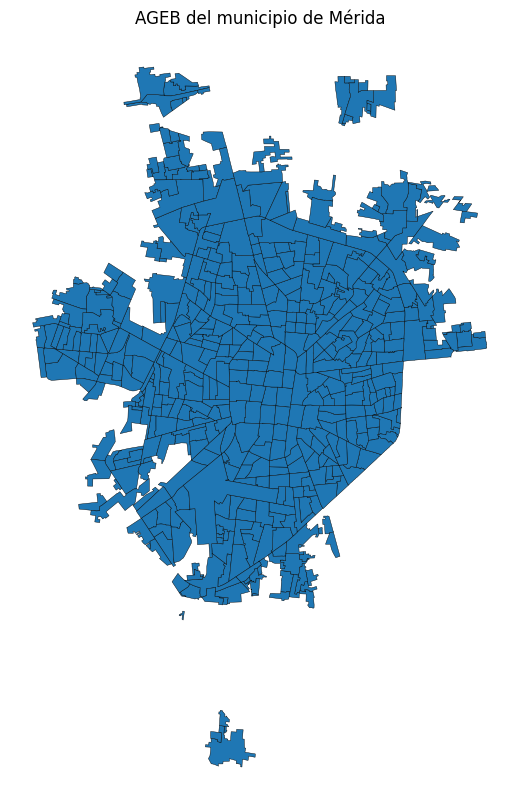

In [184]:
import matplotlib.pyplot as plt

ax = ageb_merida.plot(
    figsize=(10, 10),
    edgecolor="black",
    linewidth=0.3
)

ax.set_title("AGEB del municipio de Mérida")
ax.set_axis_off()

plt.show()

In [185]:
ageb_merida_ciudad = gdf_31a[
    (gdf_31a["CVE_MUN"] == "050") &
    (gdf_31a["CVE_LOC"] == "0001")
].copy()

print("AGEB de la ciudad de Mérida:", len(ageb_merida_ciudad))

AGEB de la ciudad de Mérida: 483


In [186]:
manzanas_merida = gdf_31m[
    (gdf_31m["CVE_MUN"] == "050") &
    (gdf_31m["CVE_LOC"] == "0001")
].copy()

print("Manzanas en Mérida:", len(manzanas_merida))

Manzanas en Mérida: 15728


In [187]:
manzanas_merida["AMBITO"].value_counts()

AMBITO
Urbana    15728
Name: count, dtype: int64

In [188]:
ageb_urbanas = set(ageb_merida_ciudad["CVE_AGEB"])

ageb_manzanas = set(
    manzanas_merida["CVE_AGEB"]
)

print("AGEB en la cartografía:", len(ageb_urbanas))
print("AGEB con manzanas:", len(ageb_manzanas))

print(
    "AGEB sin manzanas:",
    len(ageb_urbanas - ageb_manzanas)
)

AGEB en la cartografía: 483
AGEB con manzanas: 483
AGEB sin manzanas: 0


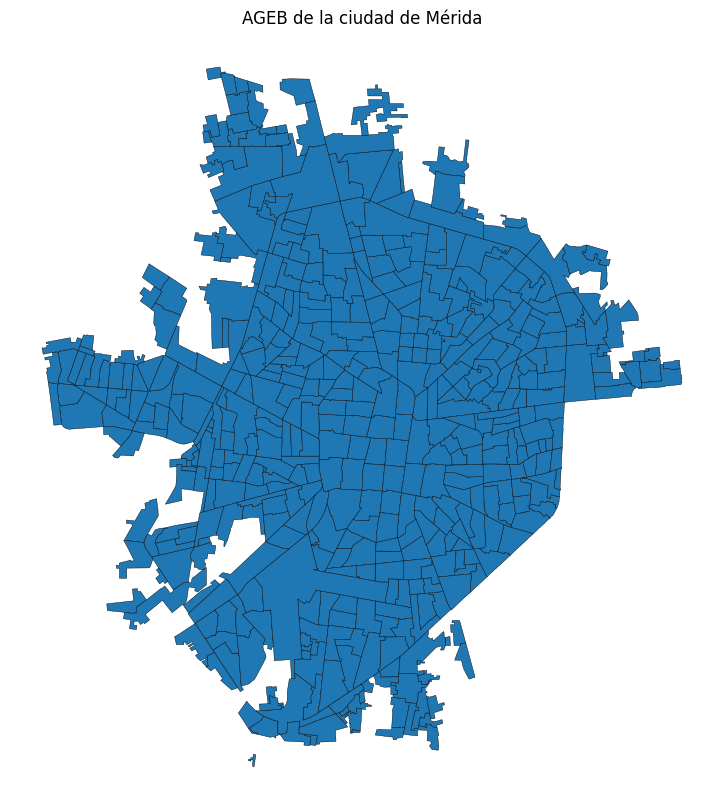

In [189]:
import matplotlib.pyplot as plt

ax = ageb_merida_ciudad.plot(
    figsize=(10, 10),
    edgecolor="black",
    linewidth=0.3
)

ax.set_title("AGEB de la ciudad de Mérida")
ax.set_axis_off()

plt.show()

## DENUE

https://www.inegi.org.mx/app/descarga/default.html 

In [125]:
import zipfile

zip_path = "../data/raw/denue_31_csv.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    print("Archivos dentro del ZIP:")
    for file in z.namelist():
        print(file)

Archivos dentro del ZIP:
diccionario_de_datos/denue_diccionario_de_datos.csv
conjunto_de_datos/denue_inegi_31_.csv
metadatos/metadatos_denue.txt


In [127]:
import pandas as pd
import zipfile

with zipfile.ZipFile("../data/raw/denue_31_csv.zip") as z:
    with z.open("conjunto_de_datos/denue_inegi_31_.csv") as f:
        denue_sample = pd.read_csv(f, nrows=5, encoding="latin-1")

print("Columns:", len(denue_sample.columns))
print(denue_sample.columns.tolist())

Columns: 42
['id', 'clee', 'nom_estab', 'raz_social', 'codigo_act', 'nombre_act', 'per_ocu', 'tipo_vial', 'nom_vial', 'tipo_v_e_1', 'nom_v_e_1', 'tipo_v_e_2', 'nom_v_e_2', 'tipo_v_e_3', 'nom_v_e_3', 'numero_ext', 'letra_ext', 'edificio', 'edificio_e', 'numero_int', 'letra_int', 'tipo_asent', 'nomb_asent', 'tipoCenCom', 'nom_CenCom', 'num_local', 'cod_postal', 'cve_ent', 'entidad', 'cve_mun', 'municipio', 'cve_loc', 'localidad', 'ageb', 'manzana', 'telefono', 'correoelec', 'www', 'tipoUniEco', 'latitud', 'longitud', 'fecha_alta']


In [128]:
with zipfile.ZipFile("../data/raw/denue_31_csv.zip") as z:
    with z.open("conjunto_de_datos/denue_inegi_31_.csv") as f:
        denue_df = pd.read_csv(
            f,
            encoding="latin-1",
            low_memory=False
        )

print("Records:", len(denue_df))
print("Columns:", len(denue_df.columns))

Records: 146384
Columns: 42


In [129]:
print(denue_df[["cve_mun", "municipio", "cve_loc", "localidad"]].head())
print(denue_df[["cve_mun", "cve_loc"]].dtypes)

   cve_mun municipio  cve_loc  \
0       59  Progreso        3   
1       38   Hunucmá        4   
2       59  Progreso        1   
3       59  Progreso        1   
4       59  Progreso        1   

                                           localidad  
0  Chelem                                        ...  
1  Sisal                                         ...  
2  Progreso                                      ...  
3  Progreso                                      ...  
4  Progreso                                      ...  
cve_mun    int64
cve_loc    int64
dtype: object


In [130]:
denue_merida = denue_df[
    (denue_df["cve_mun"] == 50) &
    (denue_df["cve_loc"] == 1)
].copy()

print("Establishments in Merida:", len(denue_merida))
print("Unique AGEBs:", denue_merida["ageb"].nunique())

denue_merida[
    ["id", "nom_estab", "codigo_act", "nombre_act",
     "ageb", "manzana", "latitud", "longitud"]
].head()

Establishments in Merida: 55059
Unique AGEBs: 482


,id,nom_estab,codigo_act,nombre_act,ageb,manzana,latitud,longitud
79,11826222,CONTROL DE PLAGAS CORMAR,115111,Servicios de fumigación agrícola,3939,15,21.019598,-89.601481
91,10383065,COSTA FISH,114119,"Pesca y captura de peces, crustáceos, moluscos...",5225,20,20.975972,-89.615679
98,6185019,CRIADERO DE PECES Y PLANTAS ACUATICAS ENMANUEL,112519,Otra acuicultura,021A,2,20.990226,-89.627434
99,6503419,CUADRA DE CABALLOS SAN RAFAEL,115210,Servicios relacionados con la cría y explotaci...,4284,13,21.062437,-89.614360
118,6472009,GARY LEE MANTENIMIENTO AGROINDUSTRIAL,115210,Servicios relacionados con la cría y explotaci...,4871,26,21.024141,-89.665726


In [131]:
ageb_denue = set(denue_merida["ageb"].astype(str).str.zfill(4))
ageb_cartography = set(ageb_merida_ciudad["CVE_AGEB"].astype(str).str.zfill(4))

print("AGEBs in cartography:", len(ageb_cartography))
print("AGEBs in DENUE:", len(ageb_denue))
print("AGEBs in both:", len(ageb_cartography & ageb_denue))
print("AGEBs only in cartography:", len(ageb_cartography - ageb_denue))
print("AGEBs only in DENUE:", len(ageb_denue - ageb_cartography))

print("\nAGEB only in cartography:")
print(ageb_cartography - ageb_denue)

AGEBs in cartography: 483
AGEBs in DENUE: 482
AGEBs in both: 473
AGEBs only in cartography: 10
AGEBs only in DENUE: 9

AGEB only in cartography:
{'6223', '6219', '5920', '6581', '6204', '0864', '4778', '6967', '4585', '676A'}


In [132]:
print("AGEBs only in DENUE:")
print(sorted(ageb_denue - ageb_cartography))

print("\nAGEBs only in cartography:")
print(sorted(ageb_cartography - ageb_denue))

AGEBs only in DENUE:
['0883', '0898', '092A', '0934', '0949', '0953', '0987', '1044', '1148']

AGEBs only in cartography:
['0864', '4585', '4778', '5920', '6204', '6219', '6223', '6581', '676A', '6967']


In [133]:
denue_missing_ageb = denue_merida[
    denue_merida["ageb"].astype(str).str.zfill(4).isin(
        ageb_denue - ageb_cartography
    )
]

denue_missing_ageb[
    [
        "ageb",
        "nom_estab",
        "nombre_act",
        "municipio",
        "localidad",
        "latitud",
        "longitud"
    ]
].head(20)

,ageb,nom_estab,nombre_act,municipio,localidad,latitud,longitud
17715,0953,PLANTA PURIFICADORA AGUA YAXJA,Purificación y embotellado de agua,Mérida,Mérida ...,20.934553,-89.709674
20024,0953,TORTILLERIA LA FLOR DEL CAMPO RA,Elaboración de tortillas de maíz y molienda de...,Mérida,Mérida ...,20.934551,-89.709800
28534,0898,ARTE Y EXPRESION,Otras industrias manufactureras,Mérida,Mérida ...,21.088278,-89.666298
29848,0934,HERRERIA SIN NOMBRE,Fabricación de productos de herrería,Mérida,Mérida ...,20.902078,-89.672848
30025,0987,KAY BUCKET,Otras industrias manufactureras,Mérida,Mérida ...,20.995699,-89.526282
31906,1148,BACHOCO,Comercio al por mayor de carne de aves,Mérida,Mérida ...,21.040523,-89.679178
36080,0987,ABARROTES HEROES,"Comercio al por menor en tiendas de abarrotes,...",Mérida,Mérida ...,20.995250,-89.528293
38897,1044,BODEGA AURRERA EXPRESS,Farmacias sin minisúper,Mérida,Mérida ...,21.016628,-89.725655
38910,0953,BODEGA AURRERA EXPRESS PASEOS DE MERIDA,Farmacias sin minisúper,Mérida,Mérida ...,20.933321,-89.710262
45260,1044,EXPENDIO DE CERVEZA CALIFORNIA,Comercio al por menor de cerveza,Mérida,Mérida ...,21.017011,-89.725478


In [134]:
print(
    denue_missing_ageb["ageb"]
    .astype(str)
    .str.zfill(4)
    .value_counts()
    .sort_index()
)

ageb
0883     7
0898     8
092A     3
0934     6
0949     4
0953    20
0987    10
1044     5
1148     1
Name: count, dtype: int64


In [135]:
import os

for root, dirs, files in os.walk("../data/raw"):
    for file in files:
        print(os.path.join(root, file))

../data/raw/.DS_Store
../data/raw/denue_31_csv.zip
../data/raw/censo_yucatan_2020.csv
../data/raw/31_yucatan.zip
../data/raw/metadatos/generico_mg_cpyv_2020.txt
../data/raw/metadatos/mg_cpyv2020_31.xml
../data/raw/metadatos/mg_cpyv2020_31.txt
../data/raw/conjunto_de_datos/31ti.dbf
../data/raw/conjunto_de_datos/31pem.shp
../data/raw/conjunto_de_datos/31ar.prj
../data/raw/conjunto_de_datos/31pe.shx
../data/raw/conjunto_de_datos/31pem.cpg
../data/raw/conjunto_de_datos/31a.shp
../data/raw/conjunto_de_datos/31ent.dbf
../data/raw/conjunto_de_datos/31sip.prj
../data/raw/conjunto_de_datos/31a.cpg
../data/raw/conjunto_de_datos/31pe.cpg
../data/raw/conjunto_de_datos/31pem.shx
../data/raw/conjunto_de_datos/31pe.shp
../data/raw/conjunto_de_datos/31mun.prj
../data/raw/conjunto_de_datos/31a.shx
../data/raw/conjunto_de_datos/31e.shx
../data/raw/conjunto_de_datos/31fm.shp
../data/raw/conjunto_de_datos/31fm.cpg
../data/raw/conjunto_de_datos/31sil.dbf
../data/raw/conjunto_de_datos/31sia.prj
../data/raw/